# 15. Classification IV: Decision Trees and Random Forests
@Shengli (Bruce) Jiang, University of South Carolina

## What We Have Covered

- Regression, regularization, and hyperparameter tuning
- Scaling, feature engineering, encoding, and missing values
- Logistic regression and classification metrics
- Support vector machines and nonlinear kernels
- Gini impurity for decision-tree splits

## What We Covered in the Last Lecture

Kernels allow an SVM to learn nonlinear decision boundaries without explicitly constructing every transformed feature.

- Polynomial degree and RBF `gamma` control model flexibility.
- Cross-validation helps us choose a kernel and its hyperparameters.
- A decision tree prefers splits that reduce Gini impurity.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Compare Gini impurity and entropy for a candidate tree split.
2. Explain how tree depth and minimum sample rules control complexity.
3. Tune and evaluate a classification tree with cross-validation.
4. Explain bootstrap sampling and random feature selection in a random forest.
5. Tune a random forest and interpret impurity-based feature importance.

## Running the Notebook

The breast cancer dataset is included with scikit-learn. Run the cells from top to bottom.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

## 1. Measuring the Quality of a Split

A classification tree tests many features and thresholds. It chooses the split that creates the cleanest child nodes.

Two common measures are Gini impurity and entropy:

$$
G=1-\sum_{k=1}^{K}p_k^2
$$

$$
H=-\sum_{k=1}^{K}p_k\log_2(p_k)
$$

We use the convention $0\log_2(0)=0$.

In [2]:
split_counts = pd.DataFrame({
    "Candidate": ["Pressure", "Pressure", "Temperature", "Temperature"],
    "Child": ["Left", "Right", "Left", "Right"],
    "Reaction": [6, 3, 3, 6],
    "No reaction": [2, 3, 4, 1]
})

display(split_counts)

,Candidate,Child,Reaction,No reaction
0,Pressure,Left,6,2
1,Pressure,Right,3,3
2,Temperature,Left,3,4
3,Temperature,Right,6,1


In [3]:
def gini(counts):
    counts = np.asarray(counts, dtype=float)
    probabilities = counts / counts.sum()
    return 1 - np.sum(probabilities ** 2)


def entropy(counts):
    counts = np.asarray(counts, dtype=float)
    probabilities = counts / counts.sum()
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))


parent_counts = np.array([9, 5])
parent_gini = gini(parent_counts)
parent_entropy = entropy(parent_counts)

split_results = []

for candidate in ["Pressure", "Temperature"]:
    rows = split_counts[split_counts["Candidate"] == candidate]
    counts = rows[["Reaction", "No reaction"]].to_numpy()
    child_sizes = counts.sum(axis=1)

    weighted_gini = np.sum(
        child_sizes / child_sizes.sum() * np.array([gini(row) for row in counts])
    )
    weighted_entropy = np.sum(
        child_sizes / child_sizes.sum() * np.array([entropy(row) for row in counts])
    )

    split_results.append({
        "Candidate": candidate,
        "Weighted Gini": weighted_gini,
        "Gini reduction": parent_gini - weighted_gini,
        "Weighted entropy": weighted_entropy,
        "Information gain": parent_entropy - weighted_entropy
    })

display(pd.DataFrame(split_results).round(3))

,Candidate,Weighted Gini,Gini reduction,Weighted entropy,Information gain
0,Pressure,0.429,0.031,0.892,0.048
1,Temperature,0.367,0.092,0.788,0.152


Both criteria select temperature:

- Its weighted Gini impurity is lower.
- Its information gain is larger.

The two criteria may produce slightly different trees, but they often choose similar splits.

## 2. Breast Cancer Classification

We use the same dataset as the kernel case study. The target is malignant or benign, and the model uses all 30 numerical features.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=26
)

print("Dataset:", X.shape)
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Classes:", [str(name) for name in cancer.target_names])

Dataset: (569, 30)
Training samples: 455
Test samples: 114
Classes: ['malignant', 'benign']


## 3. Decision-Tree Hyperparameters

- `criterion` chooses Gini impurity or entropy.
- `max_depth` limits how many levels the tree can grow.
- `min_samples_split` sets the minimum number of samples required to split a node.
- `min_samples_leaf` sets the minimum number of samples in a leaf.
- `max_features` limits the candidate features considered at each split.

Larger trees can fit more detail, but they also have a higher risk of overfitting. Trees do not require feature scaling because each rule compares one feature with one threshold.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=26)

tree_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

tree_search = GridSearchCV(
    tree, tree_grid, cv=5, scoring="accuracy"
)
tree_search.fit(X_train, y_train)

print("Best CV accuracy:", round(tree_search.best_score_, 3))
print("Best parameters:", tree_search.best_params_)

Best CV accuracy: 0.938
Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_tree = tree_search.best_estimator_
y_tree_pred = best_tree.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_tree_pred), 3))
print()
print(classification_report(y_test, y_tree_pred, target_names=cancer.target_names))

tree_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_tree_pred),
    index=[f"Actual {name}" for name in cancer.target_names],
    columns=[f"Predicted {name}" for name in cancer.target_names]
)
display(tree_confusion)

Test accuracy: 0.947

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



,Predicted malignant,Predicted benign
Actual malignant,39,3
Actual benign,3,69


### Read the Learned Rules

Each line tests one feature and threshold. Indentation shows the path from the root to a leaf.

In [7]:
from sklearn.tree import export_text

tree_rules = export_text(
    best_tree,
    feature_names=list(X.columns),
    class_names=list(cancer.target_names),
    decimals=2
)

print(tree_rules)

|--- worst perimeter <= 105.95
|   |--- worst concave points <= 0.14
|   |   |--- mean texture <= 21.57
|   |   |   |--- class: benign
|   |   |--- mean texture >  21.57
|   |   |   |--- class: benign
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 27.58
|   |   |   |--- class: benign
|   |   |--- worst texture >  27.58
|   |   |   |--- class: malignant
|--- worst perimeter >  105.95
|   |--- worst concave points <= 0.15
|   |   |--- worst perimeter <= 120.35
|   |   |   |--- class: benign
|   |   |--- worst perimeter >  120.35
|   |   |   |--- class: malignant
|   |--- worst concave points >  0.15
|   |   |--- class: malignant



### Prediction at a Leaf

A new sample follows the rules until it reaches a leaf. The predicted class comes from the class proportions among the training samples in that leaf.

In [8]:
sample = X_test.iloc[[0]]
sample_probability = best_tree.predict_proba(sample)[0]
sample_prediction = cancer.target_names[best_tree.predict(sample)[0]]

probability_table = pd.Series(
    sample_probability,
    index=cancer.target_names,
    name="Estimated probability"
)

display(sample[["mean radius", "mean texture", "worst perimeter"]])
display(probability_table.to_frame().round(3))
print("Predicted class:", sample_prediction)

,mean radius,mean texture,worst perimeter
132,16.16,21.54,129.7


,Estimated probability
malignant,1.0
benign,0.0


Predicted class: malignant


### Tree Depth and Overfitting

Training accuracy usually increases as the tree becomes deeper. Validation or test performance can stop improving when the tree begins to fit small details in the training data.

In [9]:
from sklearn.model_selection import cross_val_score

depth_results = []

for depth in [1, 2, 3, 5, 8, None]:
    depth_tree = DecisionTreeClassifier(max_depth=depth, random_state=26)
    cv_scores = cross_val_score(
        depth_tree, X_train, y_train, cv=5, scoring="accuracy"
    )
    depth_tree.fit(X_train, y_train)

    depth_results.append({
        "Maximum depth": "None" if depth is None else depth,
        "Training accuracy": depth_tree.score(X_train, y_train),
        "Mean CV accuracy": cv_scores.mean()
    })

display(pd.DataFrame(depth_results).round(3))

,Maximum depth,Training accuracy,Mean CV accuracy
0,1,0.927,0.912
1,2,0.947,0.914
2,3,0.969,0.925
3,5,0.996,0.925
4,8,1.000,0.925
5,None,1.000,0.925


## 4. Linear SVM and Decision Tree

The two models make different assumptions:

- A linear SVM learns one global linear boundary after scaling.
- A decision tree builds local if-then rules and does not require scaling.

We compare them on the same test set. The SVM settings come from the previous kernel lesson.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=10))
])
svm_model.fit(X_train, y_train)
y_svm_pred = svm_model.predict(X_test)

model_comparison = pd.DataFrame({
    "Model": ["Linear SVM", "Decision tree"],
    "Test accuracy": [
        accuracy_score(y_test, y_svm_pred),
        accuracy_score(y_test, y_tree_pred)
    ]
})

display(model_comparison.round(3))

,Model,Test accuracy
0,Linear SVM,0.982
1,Decision tree,0.947


## 5. Random Forests

A single deep tree can have high variance. A small change in the training data can produce a different tree.

A random forest creates diversity in two ways:

1. Each tree receives a bootstrap sample drawn with replacement.
2. Each split considers a random subset of the features.

The forest then averages the class probabilities from all trees.

### Bootstrap Sampling

A bootstrap sample has the same number of rows as the training set, but sampling with replacement creates duplicates. Some original rows are not selected.

In [11]:
rng = np.random.default_rng(26)
bootstrap_positions = rng.choice(
    len(X_train), size=len(X_train), replace=True
)

print("Training rows:", len(X_train))
print("Bootstrap rows:", len(bootstrap_positions))
print("Unique rows in this bootstrap sample:", len(np.unique(bootstrap_positions)))
print("First 15 sampled positions:", bootstrap_positions[:15])

Training rows: 455
Bootstrap rows: 455
Unique rows in this bootstrap sample: 286
First 15 sampled positions: [392 223 252 106 178  30 163 324 346 369 222 249 428 288 308]


### Averaging Class Probabilities

`RandomForestClassifier` averages the class probabilities from its trees. The class with the larger average probability becomes the prediction.

In [12]:
probability_example = pd.DataFrame({
    "Tree": [1, 2, 3, 4],
    "P(A)": [0.9, 0.4, 0.8, 0.3],
    "P(B)": [0.1, 0.6, 0.2, 0.7]
})

average_probability = probability_example[["P(A)", "P(B)"]].mean()

display(probability_example)
display(average_probability.rename("Average").to_frame().T)
print("Predicted class:", average_probability.idxmax()[2:-1])

,Tree,P(A),P(B)
0,1,0.9,0.1
1,2,0.4,0.6
2,3,0.8,0.2
3,4,0.3,0.7


,P(A),P(B)
Average,0.6,0.4


Predicted class: A


## 6. Random-Forest Hyperparameters

- `n_estimators` is the number of trees.
- `max_depth` controls the complexity of each tree.
- `max_features` controls how many candidate features each split considers.
- `min_samples_leaf` controls the smallest allowed leaf.

More trees usually make the prediction more stable, but the improvement eventually levels off.

In [13]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=26, n_jobs=-1)

forest_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, None],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 2, 5]
}

forest_search = GridSearchCV(
    forest, forest_grid, cv=5, scoring="accuracy", n_jobs=-1
)
forest_search.fit(X_train, y_train)

print("Best CV accuracy:", round(forest_search.best_score_, 3))
print("Best parameters:", forest_search.best_params_)

Best CV accuracy: 0.967
Best parameters: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}


In [14]:
best_forest = forest_search.best_estimator_
y_forest_pred = best_forest.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_forest_pred), 3))
print()
print(classification_report(y_test, y_forest_pred, target_names=cancer.target_names))

forest_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_forest_pred),
    index=[f"Actual {name}" for name in cancer.target_names],
    columns=[f"Predicted {name}" for name in cancer.target_names]
)
display(forest_confusion)

Test accuracy: 0.947

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



,Predicted malignant,Predicted benign
Actual malignant,39,3
Actual benign,3,69


### One Forest Prediction

The code below shows the first five tree probabilities for one test sample and then the average across the entire forest.

In [15]:
sample_array = sample.to_numpy()
tree_probabilities = np.array([
    estimator.predict_proba(sample_array)[0]
    for estimator in best_forest.estimators_
])

first_five = pd.DataFrame(
    tree_probabilities[:5], columns=cancer.target_names
)
forest_average = pd.Series(
    tree_probabilities.mean(axis=0),
    index=cancer.target_names,
    name="Forest average"
)

display(first_five.round(3))
display(forest_average.to_frame().T.round(3))
print("Forest prediction:", cancer.target_names[best_forest.predict(sample)[0]])

,malignant,benign
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


,malignant,benign
Forest average,0.99,0.01


Forest prediction: malignant


## 7. Effect of the Number of Trees

We vary only `n_estimators` and keep the other selected settings fixed. The error bars show one standard deviation across the five validation folds.

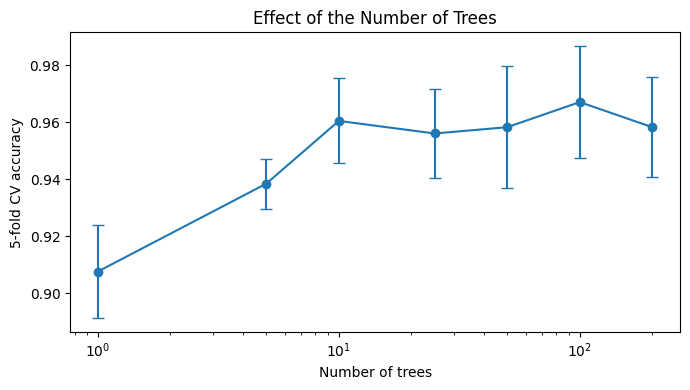

In [16]:
n_trees = [1, 5, 10, 25, 50, 100, 200]
forest_settings = forest_search.best_params_.copy()
forest_settings.pop("n_estimators")

mean_accuracy = []
std_accuracy = []

for number in n_trees:
    model = RandomForestClassifier(
        n_estimators=number,
        random_state=26,
        n_jobs=-1,
        **forest_settings
    )
    scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
    )
    mean_accuracy.append(scores.mean())
    std_accuracy.append(scores.std())

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    n_trees, mean_accuracy, yerr=std_accuracy,
    color="C0", marker="o", capsize=4
)
ax.set(
    xscale="log", xlabel="Number of trees",
    ylabel="5-fold CV accuracy", title="Effect of the Number of Trees"
)

fig.tight_layout()
plt.show()

After enough trees are included, the cross-validation accuracy becomes fairly stable. Adding more trees mainly increases computation after that point.

## 8. Impurity-Based Feature Importance

For a split, the impurity reduction is

$$
\Delta I=I_P-\frac{N_L}{N_P}I_L-\frac{N_R}{N_P}I_R.
$$

A tree adds the weighted reductions from every node that uses a feature. A random forest averages those values across its trees and normalizes them to sum to 1.

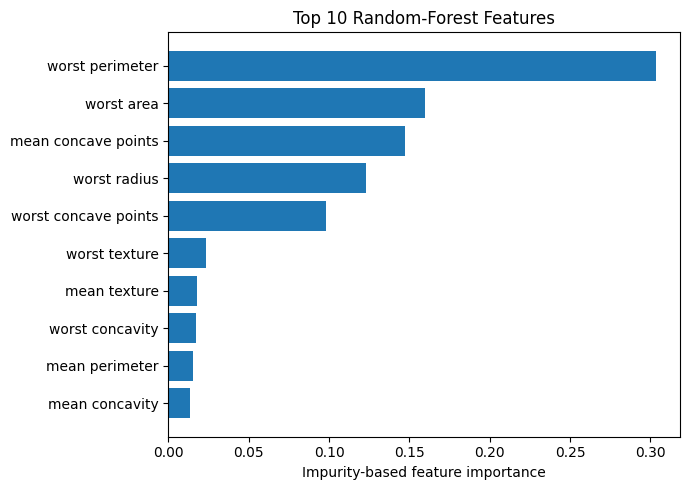

,Importance
worst perimeter,0.303
worst area,0.160
mean concave points,0.147
worst radius,0.123
worst concave points,0.098
worst texture,0.024
mean texture,0.018
worst concavity,0.017
mean perimeter,0.015
mean concavity,0.014


In [17]:
n_features_to_show = 10

importance = pd.Series(
    best_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importance.iloc[:n_features_to_show].sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_features.index, top_features.values, color="C0")
ax.set(
    xlabel="Impurity-based feature importance",
    title=f"Top {n_features_to_show} Random-Forest Features"
)

fig.tight_layout()
plt.show()

display(importance.iloc[:n_features_to_show].round(3).to_frame("Importance"))

Feature importance describes how the fitted forest used a feature. It does not prove that the feature causes the outcome. Impurity-based importance can also favor continuous features or features with many possible split points.